In [2]:
from pysilicon.hw.dataschema import DataList, IntField
from pysilicon.utils.timing import TimingDiagram, ClkSig, SigTimingInfo

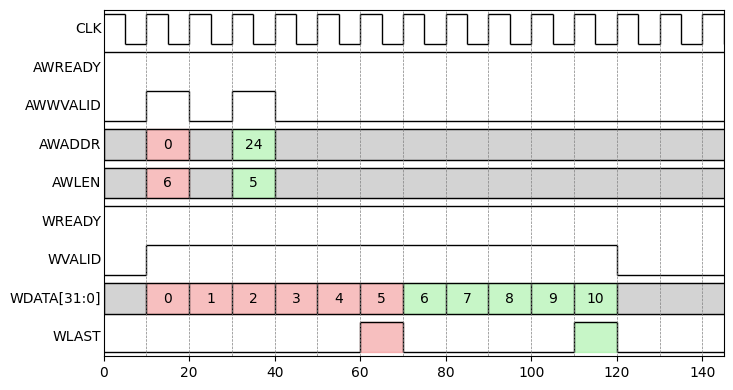

In [32]:
# Showing two bursts
ncycles = 15
clk_period = 10
clk = ClkSig(clk_name="CLK", period=clk_period, ncycles=ncycles)
p = clk.clk_periods()


burstLen = [6, 5]  # Number of data beats in each burst
ardy = [1,3]  # Clock cycle to set addr and data ready

# Setting the address for the two requests
awvalid = SigTimingInfo(
    name= "AWWVALID",
    times = [p[0], p[ardy[0]], p[ardy[0]+1], p[ardy[1]], p[ardy[1]+1]],
    values = ['0', '1', '0', '1', '0'],
)
awready = SigTimingInfo(
    name= "AWREADY",
    times = [p[0]],
    values = ['1'],
)
awaddr = SigTimingInfo(
    name= "AWADDR",
    times = [p[0], p[ardy[0]], p[ardy[0]+1], p[ardy[1]], p[ardy[1]+1]],
    values = ['x', '0', 'x', str(burstLen[0]*4), 'x'],
)
awlen = SigTimingInfo(
    name= "AWLEN",
    times = [p[0], p[ardy[0]], p[ardy[0]+1], p[ardy[1]], p[ardy[1]+1]],
    values = ['x', str(burstLen[0]), 'x', str(burstLen[1]), 'x'],
)



# Setting the data
wready = SigTimingInfo(
    name= "WREADY",
    times = [p[0]],
    values = ['1'],
)
dat_st = ardy[0]
dat_end = dat_st + burstLen[0] + burstLen[1]
wvalid = SigTimingInfo(
    name= "WVALID",
    times = [p[0], p[dat_st], p[dat_end]],
    values = ['0', '1', '0'],
)

wdatavals = ['x']
wdatatimes = [p[0]]
nbeats_tot = sum(burstLen)
for i in range(nbeats_tot):
    wdatavals.append(str(i))
    wdatatimes.append(p[dat_st + i])
wdatavals.append('x')
wdatatimes.append(p[dat_end])
wdata = SigTimingInfo(
    name= "WDATA[31:0]",
    times = wdatatimes,
    values = wdatavals
)
wlast = SigTimingInfo(
    name= "WLAST",
    times = [p[0], p[dat_st+burstLen[0]-1], p[dat_st+burstLen[0]], p[dat_end-1], p[dat_end]],
    values = ['0', '1', '0', '1', '0']
)


td = TimingDiagram()
td.add_signals([clk, awready, awvalid, awaddr, awlen])
td.add_signals([wready, wvalid, wdata, wlast])
#td.add_signals([clk, wready, wvalid, wdata])
#td.add_signals([bready,bvalid])
ax = td.plot_signals(text_mode='always', fig_width=8)

# Color the bursts
td.add_patch(sig_name="AWADDR", ind=1, color='lightcoral', alpha=0.5)
td.add_patch(sig_name="AWLEN", ind=1, color='lightcoral', alpha=0.5)
td.add_patch(sig_name="WDATA[31:0]", ind=[1, 1+burstLen[0]], color='lightcoral', alpha=0.5)
td.add_patch(sig_name="WLAST", ind=1, color='lightcoral', alpha=0.5)

td.add_patch(sig_name="AWADDR", ind=3, color='lightgreen', alpha=0.5)
td.add_patch(sig_name="AWLEN", ind=3, color='lightgreen', alpha=0.5)
td.add_patch(sig_name="WDATA[31:0]", ind=[1+burstLen[0], 1+burstLen[0]+burstLen[1]], color='lightgreen', alpha=0.5)
td.add_patch(sig_name="WLAST", ind=3, color='lightgreen', alpha=0.5)

#td.add_patch(sig_name="AWADDR[7:0]", ind=1, color='lightgreen', alpha=0.5)
#td.add_patch(sig_name="WDATA[7:0]", ind=1, color='lightblue', alpha=0.5)
#ax.set_xlabel("Time [ns]")

